In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
pd.set_option('display.float_format', lambda x: f'{x:.2f}')

df = pd.read_csv(r"C:\Users\hp\Downloads\archive (5)\Housing.csv")

print("Shape:", df.shape)
df.info()

Shape: (545, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [2]:
print("=== NULL CHECK ===")
print(df.isnull().sum())

print("\n=== DESCRIPTIVE STATISTICS ===")
df.describe()

=== NULL CHECK ===
price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

=== DESCRIPTIVE STATISTICS ===


,price,area,bedrooms,bathrooms,stories,parking
count,545.00,545.00,545.00,545.00,545.00,545.00
mean,4766729.25,5150.54,2.97,1.29,1.81,0.69
std,1870439.62,2170.14,0.74,0.50,0.87,0.86
min,1750000.00,1650.00,1.00,1.00,1.00,0.00
25%,3430000.00,3600.00,2.00,1.00,1.00,0.00
50%,4340000.00,4600.00,3.00,1.00,2.00,0.00
75%,5740000.00,6360.00,3.00,2.00,2.00,1.00
max,13300000.00,16200.00,6.00,4.00,4.00,3.00


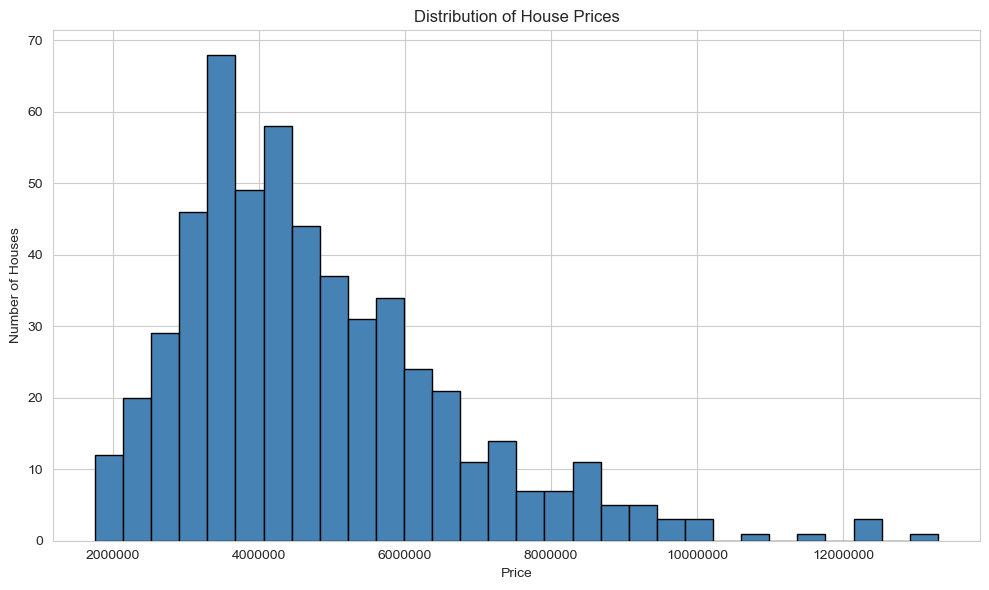

Price skewness: 1.212


In [3]:
# Distribution of the target variable (price)
plt.figure(figsize=(10,6))
plt.hist(df['price'], bins=30, color='steelblue', edgecolor='black')
plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.ylabel("Number of Houses")
plt.ticklabel_format(style='plain', axis='x')
plt.tight_layout()
plt.show()

print("Price skewness:", df['price'].skew().round(3))

EDA Summary: The dataset contains 545 houses with no missing values across any of the 13 columns. House prices range from $1.75M to $13.3M, with a right-skewed distribution (skewness = 1.21), most houses cluster between $3M–$6M, with a smaller number of high-priced outliers stretching the distribution's tail. This right-skew is common in price data and suggests that a log-transformation of price could help Linear Regression's assumptions (which work best with normally-distributed residuals), worth testing once the model is built, by comparing performance with and without the transformation.

In [4]:
#Handle categorical encoding (One-Hot Encoding)

# Binary yes/no columns — map directly to 1/0
binary_cols = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']
for col in binary_cols:
    df[col] = df[col].map({'yes': 1, 'no': 0})

# Multi-class column — One-Hot Encode
df = pd.get_dummies(df, columns=['furnishingstatus'], drop_first=True)

print(df.dtypes)
df.head()

price                              int64
area                               int64
bedrooms                           int64
bathrooms                          int64
stories                            int64
mainroad                           int64
guestroom                          int64
basement                           int64
hotwaterheating                    int64
airconditioning                    int64
parking                            int64
prefarea                           int64
furnishingstatus_semi-furnished     bool
furnishingstatus_unfurnished        bool
dtype: object


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,False,False
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,False,False
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,True,False
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,False,False
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,False,False


The six yes/no columns (mainroad, guestroom, basement, hotwaterheating, airconditioning, prefarea) were mapped directly to 1/0, since they're already binary and don't need multiple dummy columns. furnishingstatus has three categories (furnished, semi-furnished, unfurnished) and was One-Hot Encoded using drop_first=True, which creates two new binary columns (furnishingstatus_semi-furnished, furnishingstatus_unfurnished) and treats "furnished" as the baseline category — avoiding the "dummy variable trap" of perfect multicollinearity that would occur if all three category columns were kept.

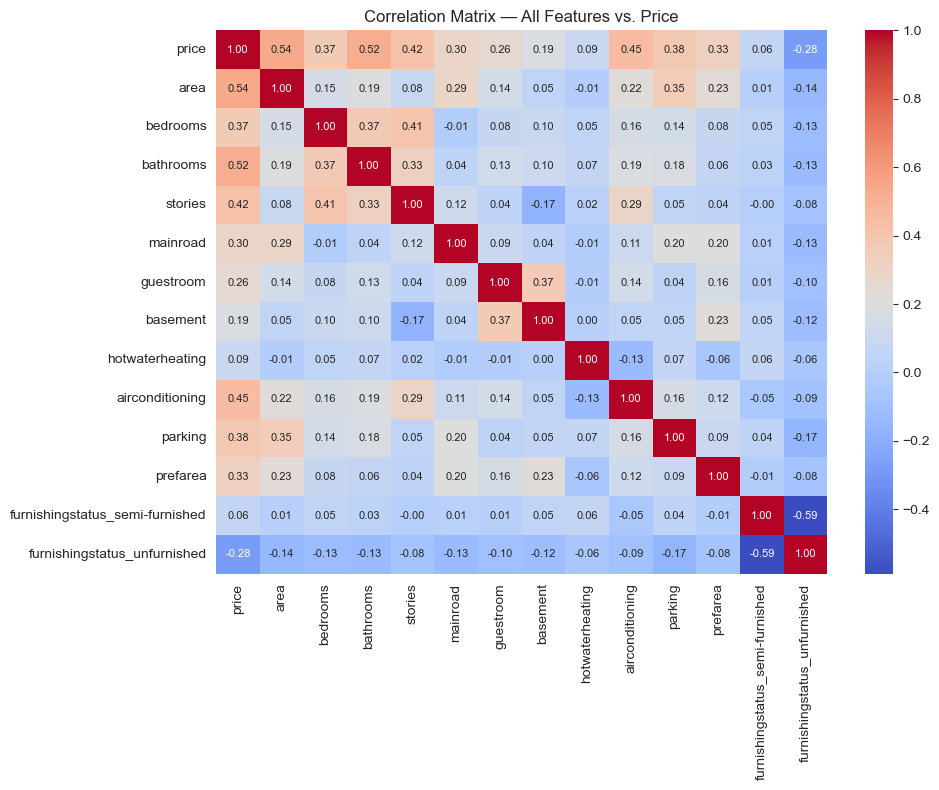

price                              1.00
area                               0.54
bathrooms                          0.52
airconditioning                    0.45
stories                            0.42
parking                            0.38
bedrooms                           0.37
prefarea                           0.33
mainroad                           0.30
guestroom                          0.26
basement                           0.19
hotwaterheating                    0.09
furnishingstatus_semi-furnished    0.06
furnishingstatus_unfurnished      -0.28
Name: price, dtype: float64


In [5]:
plt.figure(figsize=(10, 8))
corr = df.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", annot_kws={"size": 8})
plt.title("Correlation Matrix — All Features vs. Price")
plt.tight_layout()
plt.show()

# Sorted correlation with price specifically, for easy reading
print(corr['price'].sort_values(ascending=False))

In [6]:
df['furnishingstatus_semi-furnished'] = df['furnishingstatus_semi-furnished'].astype(int)
df['furnishingstatus_unfurnished'] = df['furnishingstatus_unfurnished'].astype(int)

Correlation Analysis: area (r=0.54) and bathrooms (r=0.52) show the strongest correlation with price, confirming the feature selection hypothesis. airconditioning (r=0.45) and stories (r=0.42) are also meaningful predictors. Interestingly, furnishingstatus_unfurnished shows a negative correlation (r=-0.28) — unfurnished houses tend to be cheaper, which makes intuitive sense. hotwaterheating (r=0.09) has almost no linear relationship with price, confirming it's likely a weak predictor as anticipated. No pair of predictor features shows dangerously high correlation with each other (the highest is furnishingstatus_semi-furnished vs. furnishingstatus_unfurnished at -0.59, which is expected and harmless since they're complementary dummy variables from the same original category). so multicollinearity isn't a major concern here.

In [7]:
#Train/test split
from sklearn.model_selection import train_test_split

X = df.drop('price', axis=1)
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (436, 13)
Test size: (109, 13)


In [8]:
#Train Linear Regression
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

y_pred = lr_model.predict(X_test)

print("Model trained.")

Model trained.


In [9]:
#Evaluation — MSE, RMSE, R²
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MSE: {mse:,.2f}")
print(f"RMSE: {rmse:,.2f}")
print(f"R² Score: {r2:.4f}")

MSE: 1,754,318,687,330.66
RMSE: 1,324,506.96
R² Score: 0.6529


The model achieved an R² of 0.653 on the test set, meaning it explains about 65% of the variance in house prices. RMSE was approximately $1.32M — roughly 28% of the average house price (~$4.77M) — indicating meaningful but imperfect predictive accuracy. This is a reasonable baseline for a linear model, though the unexplained variance suggests either non-linear relationships in the data, missing predictive features (e.g. exact location/neighborhood, house age, lot size), or the price outliers visible in the earlier distribution chart disproportionately affecting error.

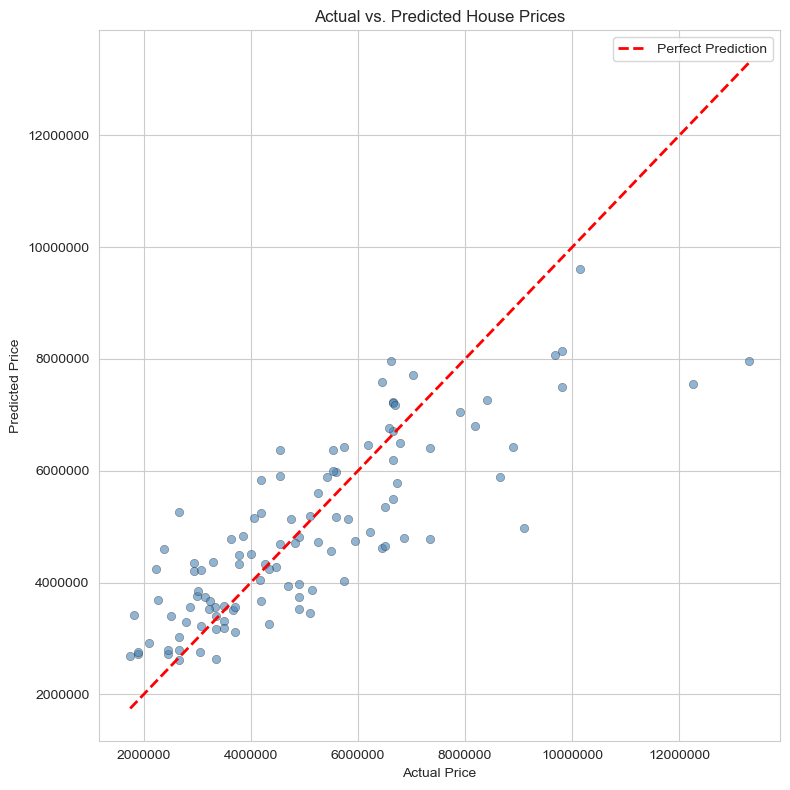

In [10]:
#Actual vs. Predicted scatter plot
plt.figure(figsize=(8,8))
plt.scatter(y_test, y_pred, alpha=0.6, color='steelblue', edgecolor='k', linewidth=0.3)

# Perfect prediction reference line
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Perfect Prediction')

plt.title("Actual vs. Predicted House Prices")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.ticklabel_format(style='plain', axis='both')
plt.legend()
plt.tight_layout()
plt.show()

Actual vs. Predicted Analysis: For houses priced below ~$6M, predictions cluster fairly close to the diagonal "perfect prediction" line, indicating reasonably accurate performance in this range. However, the model systematically underpredicts the most expensive houses — the highest-priced home in the test set (~$13.3M actual) was predicted at only ~$8M, and several other high-end houses show the same pattern (predictions capping out around $8M–$9.6M regardless of how high the actual price goes). This suggests the linear model isn't capturing whatever additional value drives the priciest homes — likely non-linear effects, or features not present in this dataset (exact neighborhood/location, lot size, unique amenities) that matter disproportionately at the high end.

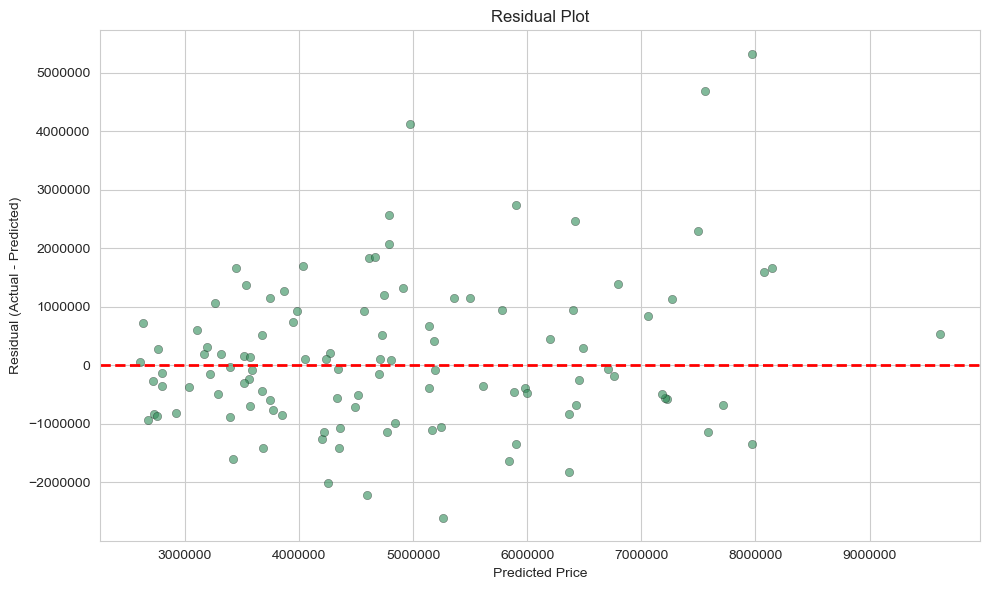

In [11]:
#Residual plot

residuals = y_test - y_pred

plt.figure(figsize=(10,6))
plt.scatter(y_pred, residuals, alpha=0.6, color='seagreen', edgecolor='k', linewidth=0.3)
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)
plt.title("Residual Plot")
plt.xlabel("Predicted Price")
plt.ylabel("Residual (Actual - Predicted)")
plt.ticklabel_format(style='plain', axis='both')
plt.tight_layout()
plt.show()

Residual Plot: Residuals are reasonably centered around zero for predicted prices between $3M–$5M, but show a clear pattern at the high end: as predicted price increases past ~$5M, residuals become both more spread out and increasingly positive (actual price higher than predicted) — visible in the large positive residuals around $5M, $7.5M, and $8M predicted price. This isn't quite a classic symmetric funnel shape, but it is a systematic pattern (increasing variance + directional bias at high prices), which violates the assumption that residuals should be randomly and evenly scattered. This confirms the same finding as the actual-vs-predicted chart: the model underestimates expensive houses, and error variance is not constant across the price range (heteroscedasticity) — both of which point toward the log-transformation of price being worth testing, since it would compress the scale of high-end errors and could make the linear relationship more consistent across price levels.

                            Feature  Coefficient
2                         bathrooms   1094444.79
8                   airconditioning    791426.74
7                   hotwaterheating    684649.89
10                         prefarea    629890.57
3                           stories    407476.59
6                          basement    390251.18
4                          mainroad    367919.95
5                         guestroom    231610.04
9                           parking    224841.91
1                          bedrooms     76778.70
0                              area       235.97
11  furnishingstatus_semi-furnished   -126881.82
12     furnishingstatus_unfurnished   -413645.06


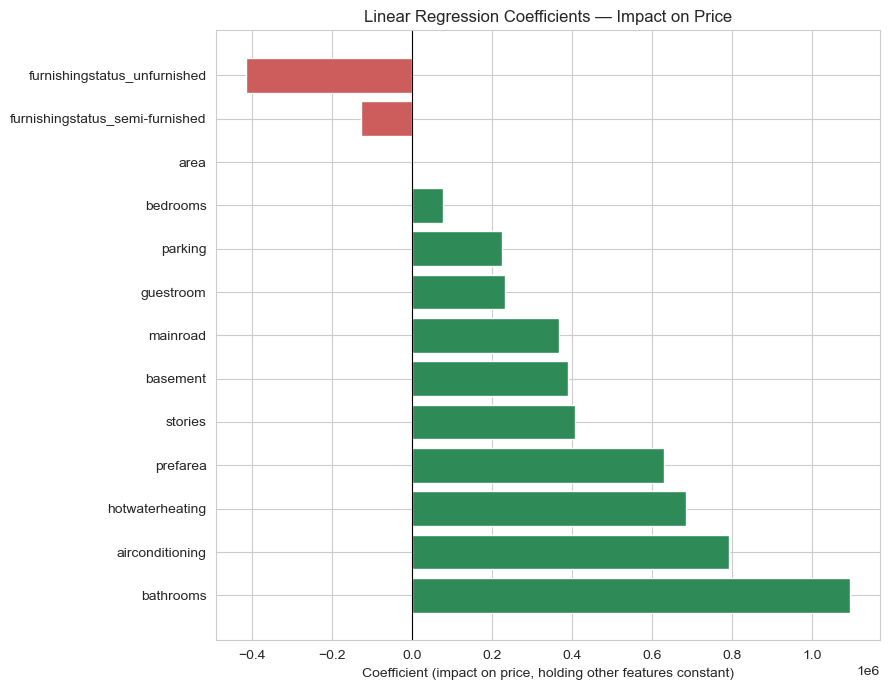

In [12]:
#Coefficient analysis

coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr_model.coef_
}).sort_values('Coefficient', ascending=False)

print(coefficients)

plt.figure(figsize=(9,7))
colors = ['seagreen' if c > 0 else 'indianred' for c in coefficients['Coefficient']]
bars = plt.barh(coefficients['Feature'], coefficients['Coefficient'], color=colors)
plt.axvline(x=0, color='black', linewidth=0.8)
plt.title("Linear Regression Coefficients — Impact on Price")
plt.xlabel("Coefficient (impact on price, holding other features constant)")
plt.tight_layout()
plt.show()

Coefficient Analysis: Holding all other features constant, bathrooms has by far the largest positive impact on price — each additional bathroom adds approximately $1,094,445, more than any other feature. airconditioning (+$791,427) and hotwaterheating (+$684,650) are the next strongest positive drivers, followed by prefarea (+$629,891) — confirming that amenities and location desirability carry substantial price premiums beyond raw size alone.

Interestingly, area — despite having the highest simple correlation with price (0.54) in the earlier heatmap — has a very small per-unit coefficient (+$236 per square foot). This isn't a contradiction: correlation measures the raw relationship, while the regression coefficient measures area's effect after accounting for bathrooms, stories, and other correlated features. Much of area's apparent influence is being captured indirectly through these more specific features once they're all considered together. bedrooms shows the same pattern (+$76,779 despite a 0.37 correlation) — it overlaps heavily with area/bathrooms/stories, so it adds little once those are already in the model.

On the negative side, furnishing status is the strongest driver of lower price: furnishingstatus_unfurnished (−$413,645) has a much larger negative effect than furnishingstatus_semi-furnished (−$126,882), relative to the fully-furnished baseline category. This is a clean, logical gradient — the less furnished a house is, the lower its price, with unfurnished homes selling for roughly $287K less than semi-furnished ones, and over $400K less than furnished ones, all else held equal.

Overall takeaway: amenities (bathrooms, air conditioning, hot water heating) and furnishing level matter more to this model's price predictions than raw square footage or bedroom count — a genuinely useful, non-obvious insight for anyone using this model to guide pricing or renovation decisions.

In [13]:
#Ridge & Lasso comparison

from sklearn.linear_model import Ridge, Lasso

ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train, y_train)
ridge_pred = ridge_model.predict(X_test)

lasso_model = Lasso(alpha=1000)
lasso_model.fit(X_train, y_train)
lasso_pred = lasso_model.predict(X_test)

def get_metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    return mse, rmse, r2

results = pd.DataFrame({
    'Model': ['Linear Regression', 'Ridge', 'Lasso'],
    'MSE': [mean_squared_error(y_test, y_pred), *[get_metrics(y_test, p)[0] for p in [ridge_pred, lasso_pred]]],
    'RMSE': [rmse, *[get_metrics(y_test, p)[1] for p in [ridge_pred, lasso_pred]]],
    'R2': [r2, *[get_metrics(y_test, p)[2] for p in [ridge_pred, lasso_pred]]]
})
results

,Model,MSE,RMSE,R2
0,Linear Regression,1754318687330.66,1324506.96,0.65
1,Ridge,1756474279575.29,1325320.44,0.65
2,Lasso,1756953599243.18,1325501.26,0.65


 Ridge & Lasso Comparison: Ridge (R²=0.6524) and Lasso (R²=0.6523) performed virtually identically to plain Linear Regression (R²=0.6529) — differences of less than 0.001 in R² and under 1,000 in RMSE, which is negligible given RMSE is already over $1.3M. This is a meaningful finding in itself: regularization didn't help, which suggests the original Linear Regression model wasn't meaningfully overfitting or suffering from problematic multicollinearity in the first place — consistent with the correlation heatmap earlier, where no predictor pair showed dangerously high correlation (aside from the two furnishing status dummies, which are expected to be linked by construction).

This tells us the model's limitation isn't about coefficient instability or overfitting to noise — it's more likely about missing information (e.g. exact location, lot size, house age/condition — none of which are in this dataset) or a non-linear relationship between features and price, particularly at the high end of the price range, as seen in the earlier residual plot. Regularization can't fix either of those problems, since it only constrains coefficient size — it doesn't add new information or model non-linear patterns. A next step worth mentioning (even if not implemented here) would be trying a non-linear model (e.g. Random Forest or Gradient Boosting) or engineering interaction features, to see if either better captures the high-price underprediction pattern.

## Conclusion

The Linear Regression model explained approximately 65% of the variance in house prices (R² = 0.653), with an RMSE of ~$1.32M (about 28% of the average house price). Ridge and Lasso regularization produced virtually identical results, indicating the model wasn't overfitting or suffering from serious multicollinearity — the limiting factor is more likely missing predictive features (exact location, lot size, house age/condition) and non-linear price effects, particularly at the high end of the market, where the model consistently underpredicted the most expensive homes.

**Key findings:**
- `bathrooms`, `airconditioning`, and `hotwaterheating` had the largest positive impact on price per unit, more than raw square footage.
- `area`, despite having the highest simple correlation with price, contributed a surprisingly small per-unit effect once other correlated features (bathrooms, stories) were accounted for.
- Furnishing status showed a clear, logical gradient: unfurnished homes sold for substantially less than furnished ones, all else equal.
- The model systematically underpredicts high-end homes (>$8M), suggesting non-linear pricing dynamics or missing luxury-specific features not captured in this dataset.

**Recommendation for future improvement:** incorporate location-specific data (neighborhood, school district, or geographic coordinates), house age/condition, and lot size if available, and test a non-linear model (Random Forest or Gradient Boosting) to better capture high-end price behavior.